# Pretraining on Unlabeled Data

## Evaluating generative text models

### Using GPT to generate text

In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'
import torch
from previous_chapters import GPTModel

# GPT_CONFIG_NANO = {
#     "vocab_size": 50257,   # Vocabulary size
#     "context_length": 256, # Shortened context length (orig: 1024)
#     "emb_dim": 1536,        # Embedding dimension
#     "n_heads": 24,         # Number of attention heads
#     "n_layers": 24,        # Number of layers
#     "drop_rate": 0.1,      # Dropout rate
#     "qkv_bias": False      # Query-key-value bias
# }


# GPT_CONFIG_NANO = {
#     "vocab_size": 50257,   # Vocabulary size
#     "context_length": 256, # Shortened context length (orig: 1024)
#     "emb_dim": 1024,        # Embedding dimension
#     "n_heads": 16,         # Number of attention heads
#     "n_layers": 24,        # Number of layers
#     "drop_rate": 0.1,      # Dropout rate
#     "qkv_bias": False      # Query-key-value bias
# }

# Optimal for ~240k pre-training tokens
GPT_CONFIG_NANO = {
    "vocab_size": 2048,
    "context_length": 256, 
    "emb_dim": 384,       # Scaled down from 768
    "n_heads": 6,         # Standard head dim of 32 (256/8)
    "n_layers": 6,        # Deep enough to learn logic, light enough for small data
    "drop_rate": 0.2,      # Higher dropout is CRITICAL here
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_NANO)
model.eval();

In [39]:
# import tiktoken
# from previous_chapters import generate_text_simple

# def text_to_token_ids(text, tokenizer):
#     encoded = tokenizer.encode(text, allowed_special = {"<|endoftext|>"})
#     encoded_tensor = torch.tensor(encoded).unsqueeze(0)
#     return encoded_tensor

# def token_ids_to_text(token_ids, tokenizer):
#     flat = token_ids.squeeze(0)
#     return tokenizer.decode(flat.tolist())

# start_context = "Every effort moves you"
# tokenizer = tiktoken.get_encoding("gpt2")

# token_ids = generate_text_simple(
#     model = model,
#     idx = text_to_token_ids(start_context, tokenizer),
#     max_new_tokens = 10,
#     context_size=GPT_CONFIG_NANO["context_length"]
# )

# print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

In [3]:
from tokenizer_base.regex1 import RegexTokenizer 
from previous_chapters import generate_text_simple
def load_custom_tokenizer(model_path):
    """
    Loads the custom regex.model and regex.vocab files.
    """
    tokenizer = RegexTokenizer()
    # Loading typically expects the prefix without extension if following minbpe patterns
    # or the specific .model file.
    tokenizer.load(model_path) 
    return tokenizer

# Usage
# If your files are 'regex.model' and 'regex.vocab' in the current directory:
tokenizer = load_custom_tokenizer(r"D:\Aryan\Projects\TrainGPT\GPT\tokenizer_base\models\regex.model")
start_context = "Every effort moves you"
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special = {"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens = 10,
    context_size=GPT_CONFIG_NANO["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you standalonealth�enerok Ltd remainnualsequent Total


## Culating the text generation loss: cross-entropy and perplexity

In [4]:
# inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
#                        [40,    1107, 588]])   #  "I really like"]

# targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
#                         [1107,  588, 11311]]) #  " really like chocolate"]

In [ ]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim = -1)
print(probas.shape)

In [3]:
logits


NameError: name 'logits' is not defined

In [4]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

NameError: name 'probas' is not defined

In [5]:
print(f"Targets batch 1 : {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1 : {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

NameError: name 'targets' is not defined

In [6]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:- ", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

NameError: name 'probas' is not defined

In [7]:
listi = torch.tensor([[[1,2,3,4,5],
                       [6,7,8,9,10],
                       [11,12,13,14,15]],
                      [[16,17,18,19,20],
                      [21,22,23,24,25],
                      [26,27,28,29,30]]])

In [8]:
listi.shape

torch.Size([2, 3, 5])

In [9]:
abc = torch.argmax(listi, dim =-1 , keepdim= True)
print(abc)

tensor([[[4],
         [4],
         [4]],

        [[4],
         [4],
         [4]]])


In [10]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

NameError: name 'targets' is not defined

In [11]:
text_ids = 0
target_probaas_1 = probas[text_ids, [0, 1, 2], targets[text_ids]]
print("Text 1:", target_probas_1)

text_ids = 1
target_proabas_2 = probas[text_ids, [0, 1, 2], targets[text_ids]]
print("Text 2:", target_probas_2)

NameError: name 'probas' is not defined

In [12]:
targets[text_ids]

NameError: name 'targets' is not defined

In [13]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)
# For logarithmic functions, smaller input values (between 0 and 1) produce larger negative outputs. The closer the value is to zero, the more negative the logarithm becomes.

NameError: name 'target_probas_1' is not defined

In [14]:
-1*torch.mean(log_probas) # this is the cross entropy loss

NameError: name 'log_probas' is not defined

In [15]:
# tensor(10.7940) we want this value to be close to zero for good response

In [16]:
logits.shape

NameError: name 'logits' is not defined

In [17]:
logits_flat = logits.flatten(0, 1)
logits_flat.shape

NameError: name 'logits' is not defined

In [18]:
targets

NameError: name 'targets' is not defined

In [19]:
targets.shape

NameError: name 'targets' is not defined

In [20]:
targets_flat = targets.flatten()
targets_flat.shape

NameError: name 'targets' is not defined

In [21]:
targets_flat

NameError: name 'targets_flat' is not defined

In [22]:
torch.nn.functional.cross_entropy(logits_flat, targets_flat)

NameError: name 'logits_flat' is not defined

## 5.1.3 Calculating the training and validation set losses

In [4]:
file_path = r"D:\Aryan\Projects\TrainGPT\GPT\data\New_Solar_Report_cleaned.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()
text_data

'Power to Propel the Future\n\nAbout the Report\n\nThis is Solar\'s Integrated Annual Report for FY 2024-25, providing a comprehensive assessment of financial and non-financial metrics. This report covers the financial year from April 01, 2024, to March 31, 2025 .\n\nThis Report is prepared in accordance with the International Integrated Reporting Framework published by the International Integrated Reporting Council (IIRC). We have also followed guidelines and commitments outlined in the GRI Standards, Sustainable Development Goals (SDGs), and other relevant standards and frameworks.\n\nForward-looking statements\n\nSome information in this report may contain forward-looking statements which include statements regarding Company\'s expected financial position and results of operations, business plans and prospects, and are generally identified by forward-looking words such as \'believe,\' \'plan,\' \'anticipate,\' \'continue,\' \'estimate,\' \'expect,\' \'may,\' \'will\' or other simila

In [5]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 1072247
Tokens: 326697


In [7]:
from previous_chapters_own_toke import create_dataloader_v1

train_ratio = 0.90
split_idx =  int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size = 64,
    max_length = GPT_CONFIG_NANO['context_length'],
    stride = GPT_CONFIG_NANO['context_length'],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size = 64,
    max_length = GPT_CONFIG_NANO['context_length'],
    stride = GPT_CONFIG_NANO['context_length'],
    drop_last = False,
    shuffle = False,
    num_workers = 0
)

In [8]:
print("Train Loader")
i = 0
for x, y in train_loader:
    print(x.shape, y.shape)
    i = i + 1
print(i)

Train Loader
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
17


In [9]:
print("Train Loader")
i = 1
for x, y in train_loader:
    print(f'X :- {x}')
    print(f'Y :- {y}')
    print(f'Batch :- {i}\n-------------------------------------------------------------------------------------------------')
    i += 1
print(i)

Train Loader
X :- tensor([[ 267, 1507, 1308,  ..., 1797, 1076,  472],
        [ 597,   41,  343,  ...,  986, 1276,  982],
        [ 275,  267, 1059,  ..., 1451, 1718,  412],
        ...,
        [1881, 1085,  374,  ...,  666,  628,   32],
        [ 320,  297,  275,  ...,  693,   46,   32],
        [  46, 1468,   32,  ..., 1048,   41,  304]])
Y :- tensor([[1507, 1308,  267,  ..., 1076,  472,  385],
        [  41,  343, 1228,  ..., 1276,  982, 1098],
        [ 267, 1059,  426,  ..., 1718,  412, 1709],
        ...,
        [1085,  374,   32,  ...,  628,   32,  615],
        [ 297,  275,  267,  ...,   46,   32,  874],
        [1468,   32,   48,  ...,   41,  304,   48]])
Batch :- 1
-------------------------------------------------------------------------------------------------
X :- tensor([[  99,  337,   80,  ...,   32,  648,   52],
        [ 505,  108,  539,  ...,  562,  422,  352],
        [  44, 1714,   44,  ...,   44,   50,  815],
        ...,
        [ 948, 1512,  279,  ..., 1239,   3

In [10]:
print("Val Loader")
i = 1
for x, y in val_loader:
    print(x.shape, y.shape)
    i+=1
print(i)

Val Loader
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([64, 256]) torch.Size([64, 256])
torch.Size([11, 256]) torch.Size([11, 256])
4


In [11]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 278528
Validation tokens: 35584
All tokens: 314112


In [12]:
torch.cuda.is_available()

True

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [14]:
model.to(device);

In [15]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss+= loss.item()
        else:
            break
    return total_loss / num_batches

In [16]:
# torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 7.778208003324621
Validation loss: 7.771727561950684


In [17]:
# perplexlity
torch.exp(torch.tensor([10.972490858112822]))

tensor([58249.5273])

In [18]:
# tensor([58249.5273]) this value is the value which tell us how many tokens is not known by model

In [19]:
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')


12.311808 M parameters


# 5.2 Training an LLM

In [20]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                      eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            # Eval step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}):"
                     f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    
    return train_losses , val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches = eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches = eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
        model = model, idx=encoded,
        max_new_tokens=50, context_size=context_size
        )
    decode_text = token_ids_to_text(token_ids, tokenizer)
    print(decode_text.replace("\n", " "))
    model.train()

In [35]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_NANO)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0003, weight_decay=0.1)

num_epochs = 50
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Shri Narendra Modi Ji", tokenizer=tokenizer
)

Ep 1 (Step 000000):Train loss 7.547, Val loss 7.522
Ep 1 (Step 000005):Train loss 6.842, Val loss 6.776
Ep 1 (Step 000010):Train loss 6.586, Val loss 6.526
Ep 1 (Step 000015):Train loss 6.412, Val loss 6.384
Shri Narendra Modi Ji the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Ep 2 (Step 000020):Train loss 6.320, Val loss 6.276
Ep 2 (Step 000025):Train loss 6.249, Val loss 6.186
Ep 2 (Step 000030):Train loss 6.138, Val loss 6.104
Shri Narendra Modi Ji, 2025. The the Company, 31, 31, 2024. The the Company 31, 31, 31, 31, 31, 2024. The the Company 31, 31,
Ep 3 (Step 000035):Train loss 6.041, Val loss 6.022
Ep 3 (Step 000040):Train loss 5.955, Val loss 5.963
Ep 3 (Step 000045):Train loss 5.838, Val loss 5.878
Ep 3 (Step 000050):Train loss 5.737, Val loss 5.815
Shri Narendra Modi Ji, 2025. The Company 2024. The Company. The Company, 2025. T

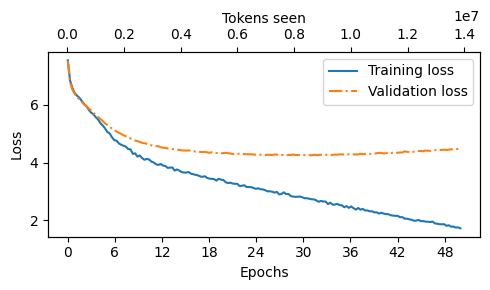

In [36]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 5.3 Decoding strategies to control randomness

In [37]:
inference_device = torch.device("cuda")
model.to(inference_device)
model.eval()

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Shareholder", tokenizer).to(inference_device),
    max_new_tokens=100,
    context_size=GPT_CONFIG_NANO["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Shareholder and the Company's website and the Company's website of Directors and other information and the Company and other information and other financial controls with reference to consolidated financial statements of the Company. The Company's website and other auditors on the Company's website of the financial statements, 2013, the Company and the Company and the financial statements, 2013, the Company's financial controls with the financial statements, as required under Section 2013, the consolidated financial statements, the Company and the Company's website


In [38]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

inverse_vocab = {v:k for k,v in vocab.items()}
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
probas = torch.softmax(next_token_logits, dim = -1)
next_token_id = torch.argmax(probas).item()

print(inverse_vocab[next_token_id])

forward


In [39]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples = 1).item()
print(inverse_vocab[next_token_id])

forward


In [40]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples = 1).item() for i in range(1000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


In [41]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim = 0)

temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

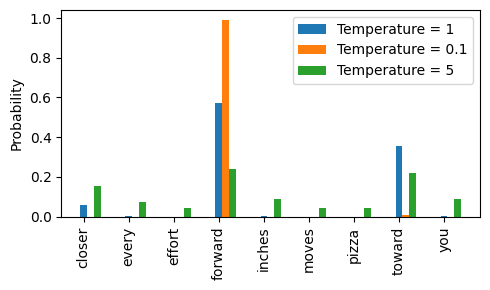

In [42]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

In [43]:
torch.save(model.state_dict(), "model_nano.pth")

In [44]:
model.load_state_dict(torch.load("model_nano.pth", map_location=device, weights_only=True))
model.eval();

In [45]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer_nano.pth"
)

In [46]:
checkpoint = torch.load("model_and_optimizer_nano.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_NANO)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.eval();

In [47]:
inference_device = torch.device("cuda")
model.to(inference_device)
model.eval()

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Satyanarayan Nuwal is ", tokenizer).to(inference_device),
    max_new_tokens=100,
    context_size=GPT_CONFIG_NANO["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Satyanarayan Nuwal is 5.00% of the Company's website of the Company. The Company's approval of the Company's financial year under review, the Company's website and other financial controls with the Company.

The Company's website i. The Company has not applicable laws given by Audit has not applicable to the Company has not a financial year under review the Company has not 2013. The Company has not applicable to the financial statements, the Company has not applicable laws, the Company and the Company has not applicable to
